# Ontology Engineering — Capability Model demo

Loads the capability model (business & technology capabilities, arranged as a taxonomy + ontology, mapped to the **EKGF EKG Maturity Model**) and exercises every generator: Mermaid, ArchiMate SVG, RDF/Turtle and the networkx ontology visualisation.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # import the package
import matplotlib
matplotlib.use('Agg')
import ontology_engineering_capabilities as oec
print('capabilities:', len(oec.CAPABILITIES), '| categories:', len(oec.CATEGORIES))
print('model issues :', oec.validate_model() or 'none')

capabilities: 44 | categories: 10
model issues : none


## 1 · Requirements table (a slice)

In [2]:
import pandas as pd
df = pd.DataFrame([{
    'id': c.id, 'domain': c.domain, 'category': oec.CATEGORY_BY_ID[c.category].name,
    'capability': c.name, 'pillar': c.ekgf_pillar, 'level': c.maturity_level,
    'requirement': c.requirement,
} for c in oec.CAPABILITIES])
print('shape:', df.shape)
df.head(12)

shape: (44, 7)


,id,domain,category,capability,pillar,level,requirement
0,B.SG.1,Business,Ontology Strategy & Governance,Ontology Vision & Strategy,Business,1,The practice shall maintain an explicit ontolo...
1,B.SG.2,Business,Ontology Strategy & Governance,Ontology Governance & Stewardship,Data,3,The practice shall establish governance bodies...
2,B.SG.3,Business,Ontology Strategy & Governance,"Policy, Standards & Conventions Management",Data,3,The practice shall publish and enforce ontolog...
3,B.SG.4,Business,Ontology Strategy & Governance,Funding & Investment Management,Organization,2,The practice shall secure sustained funding ti...
4,B.SG.5,Business,Ontology Strategy & Governance,Ontology Risk & Compliance Management,Data,4,The practice shall identify and mitigate risks...
5,B.SE.1,Business,Stakeholder & Domain Engagement,Domain Knowledge Elicitation,Business,1,The practice shall systematically elicit and r...
6,B.SE.2,Business,Stakeholder & Domain Engagement,Competency Question Management,Business,1,The practice shall define and maintain compete...
7,B.SE.3,Business,Stakeholder & Domain Engagement,Use-Case & Requirements Management,Organization,1,"The practice shall manage prioritised, traceab..."
8,B.SE.4,Business,Stakeholder & Domain Engagement,Business Glossary & Terminology Management,Data,2,The practice shall maintain an authoritative b...
9,B.VP.1,Business,Value & Performance Management,Value Case & Benefits Realization,Business,4,The practice shall quantify and track the real...


In [3]:
# capabilities per EKGF maturity level
df.groupby('level').size().rename('count').to_frame()

,count
level,
1,5
2,14
3,15
4,7
5,3


## 2 · Taxonomy graph (networkx)

In [4]:
tax = oec.build_taxonomy_graph()
import networkx as nx
print('nodes:', tax.number_of_nodes(), 'edges:', tax.number_of_edges())
print('is tree (DAG):', nx.is_directed_acyclic_graph(tax))

nodes: 57 edges: 56
is tree (DAG): True


## 3 · Mermaid diagrams
Source renders on GitHub / mermaid.live / VS Code.

In [5]:
mmd = oec.to_mermaid_taxonomy()
print(mmd[:700], '\n...')

%% Ontology Engineering Capability Model - Taxonomy + EKGF maturity level
flowchart TB
  classDef biz fill:#FFE0B2,stroke:#E65100,color:#000;
  classDef tech fill:#BBDEFB,stroke:#0D47A1,color:#000;
  classDef cat fill:#ECEFF1,stroke:#455A64,color:#000,font-weight:bold;
  ROOT(["Ontology Engineering Capabilities"]):::cat
  subgraph DOM_Business["Business Capabilities"]
    direction TB
    subgraph CAT_BSG["BSG · Ontology Strategy & Governance"]
      direction TB
      B_SG_1["B.SG.1 Ontology Vision & Strategy<br/><i>L1 · Business</i>"]:::biz
      B_SG_2["B.SG.2 Ontology Governance & Stewardship<br/><i>L3 · Data</i>"]:::biz
      B_SG_3["B.SG.3 Policy, Standards & Conventions Management<br/ 
...


## 4 · ArchiMate capability map (SVG + raster preview)

SVG bytes: 34525 | raster: artifacts/_demo_map.png


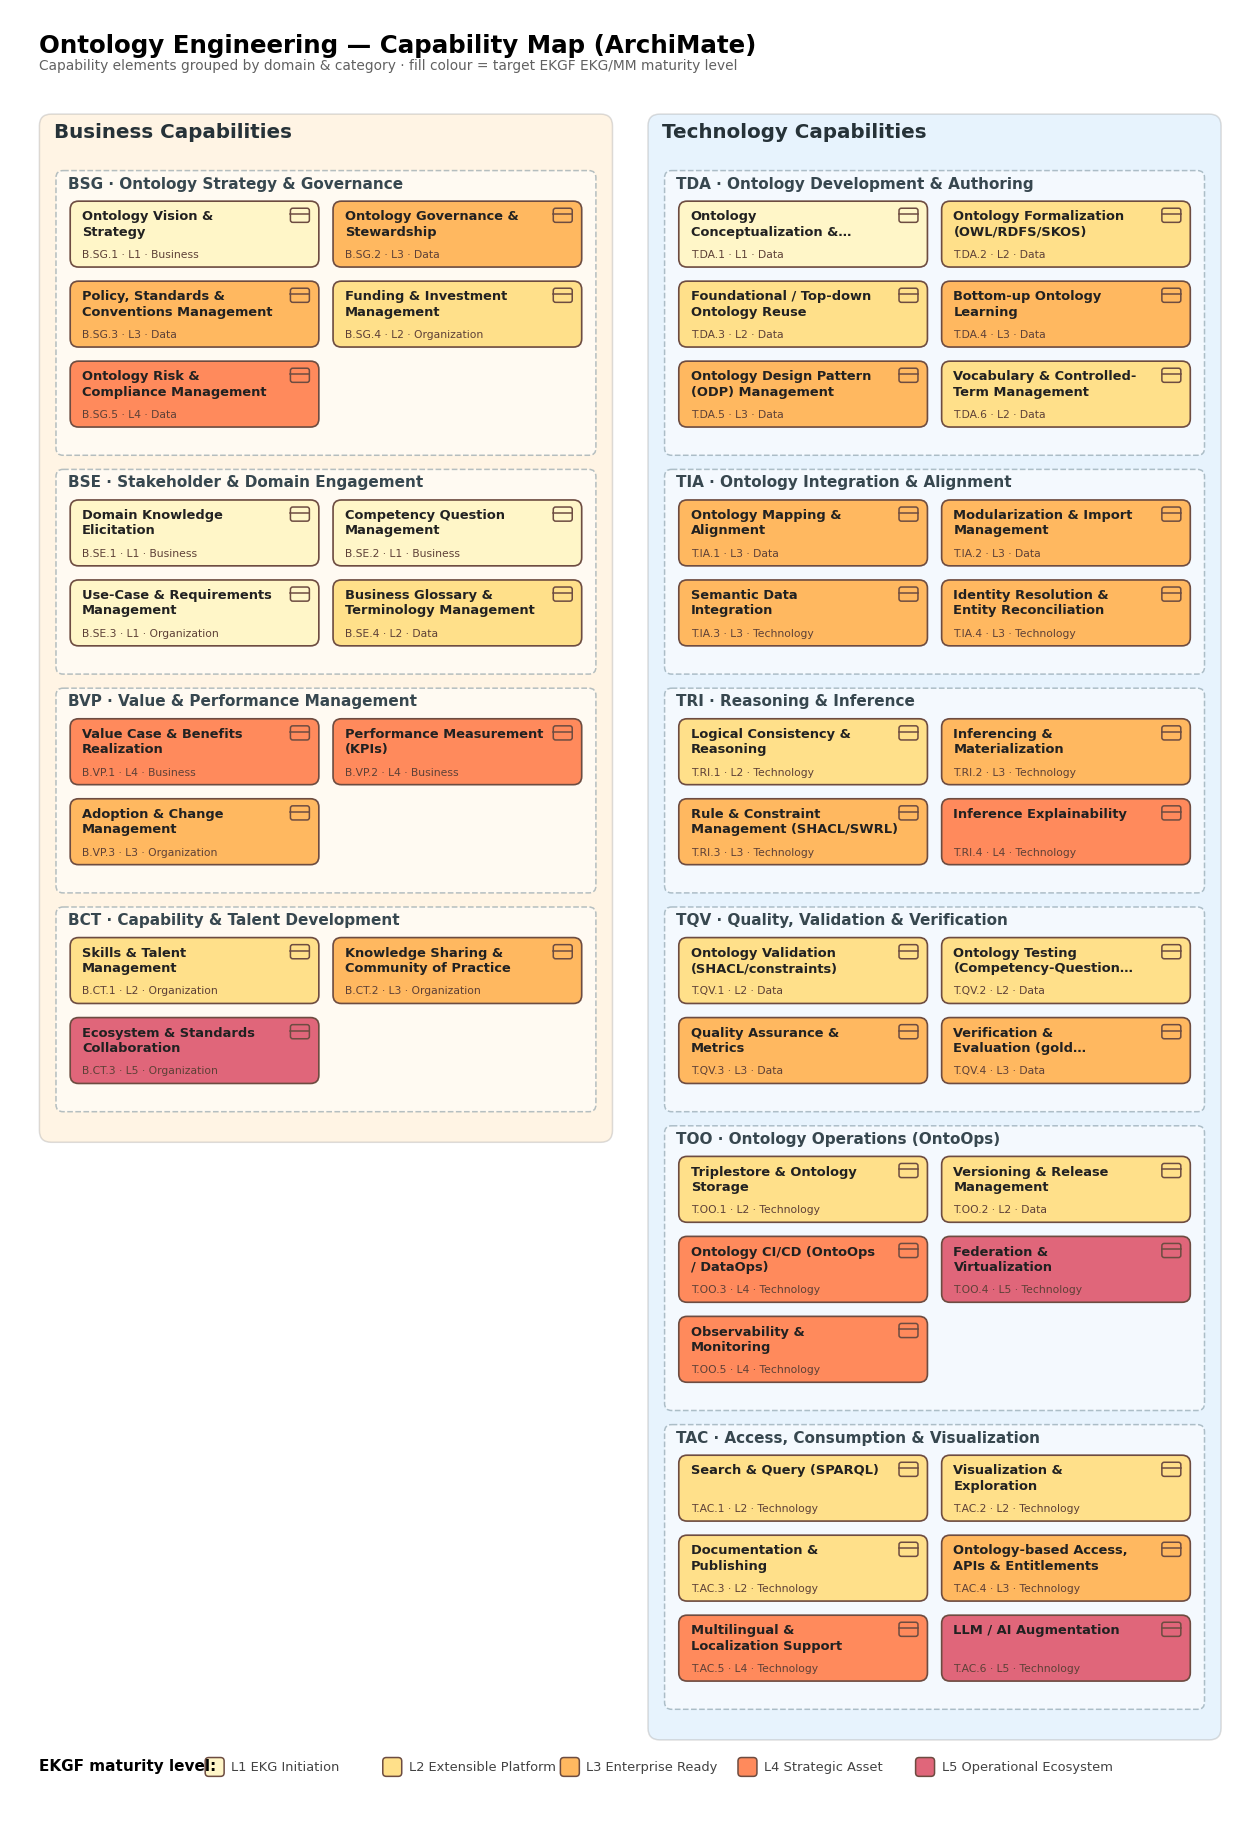

In [6]:
svg = oec.to_archimate_svg()
open('artifacts/_demo_map.svg', 'w', encoding='utf-8').write(svg)
png = oec.draw_archimate_png('artifacts/_demo_map.png')
print('SVG bytes:', len(svg), '| raster:', png)
from IPython.display import Image, SVG, display
display(Image(filename=png))

## 5 · Capability ontology visualisation (networkx)

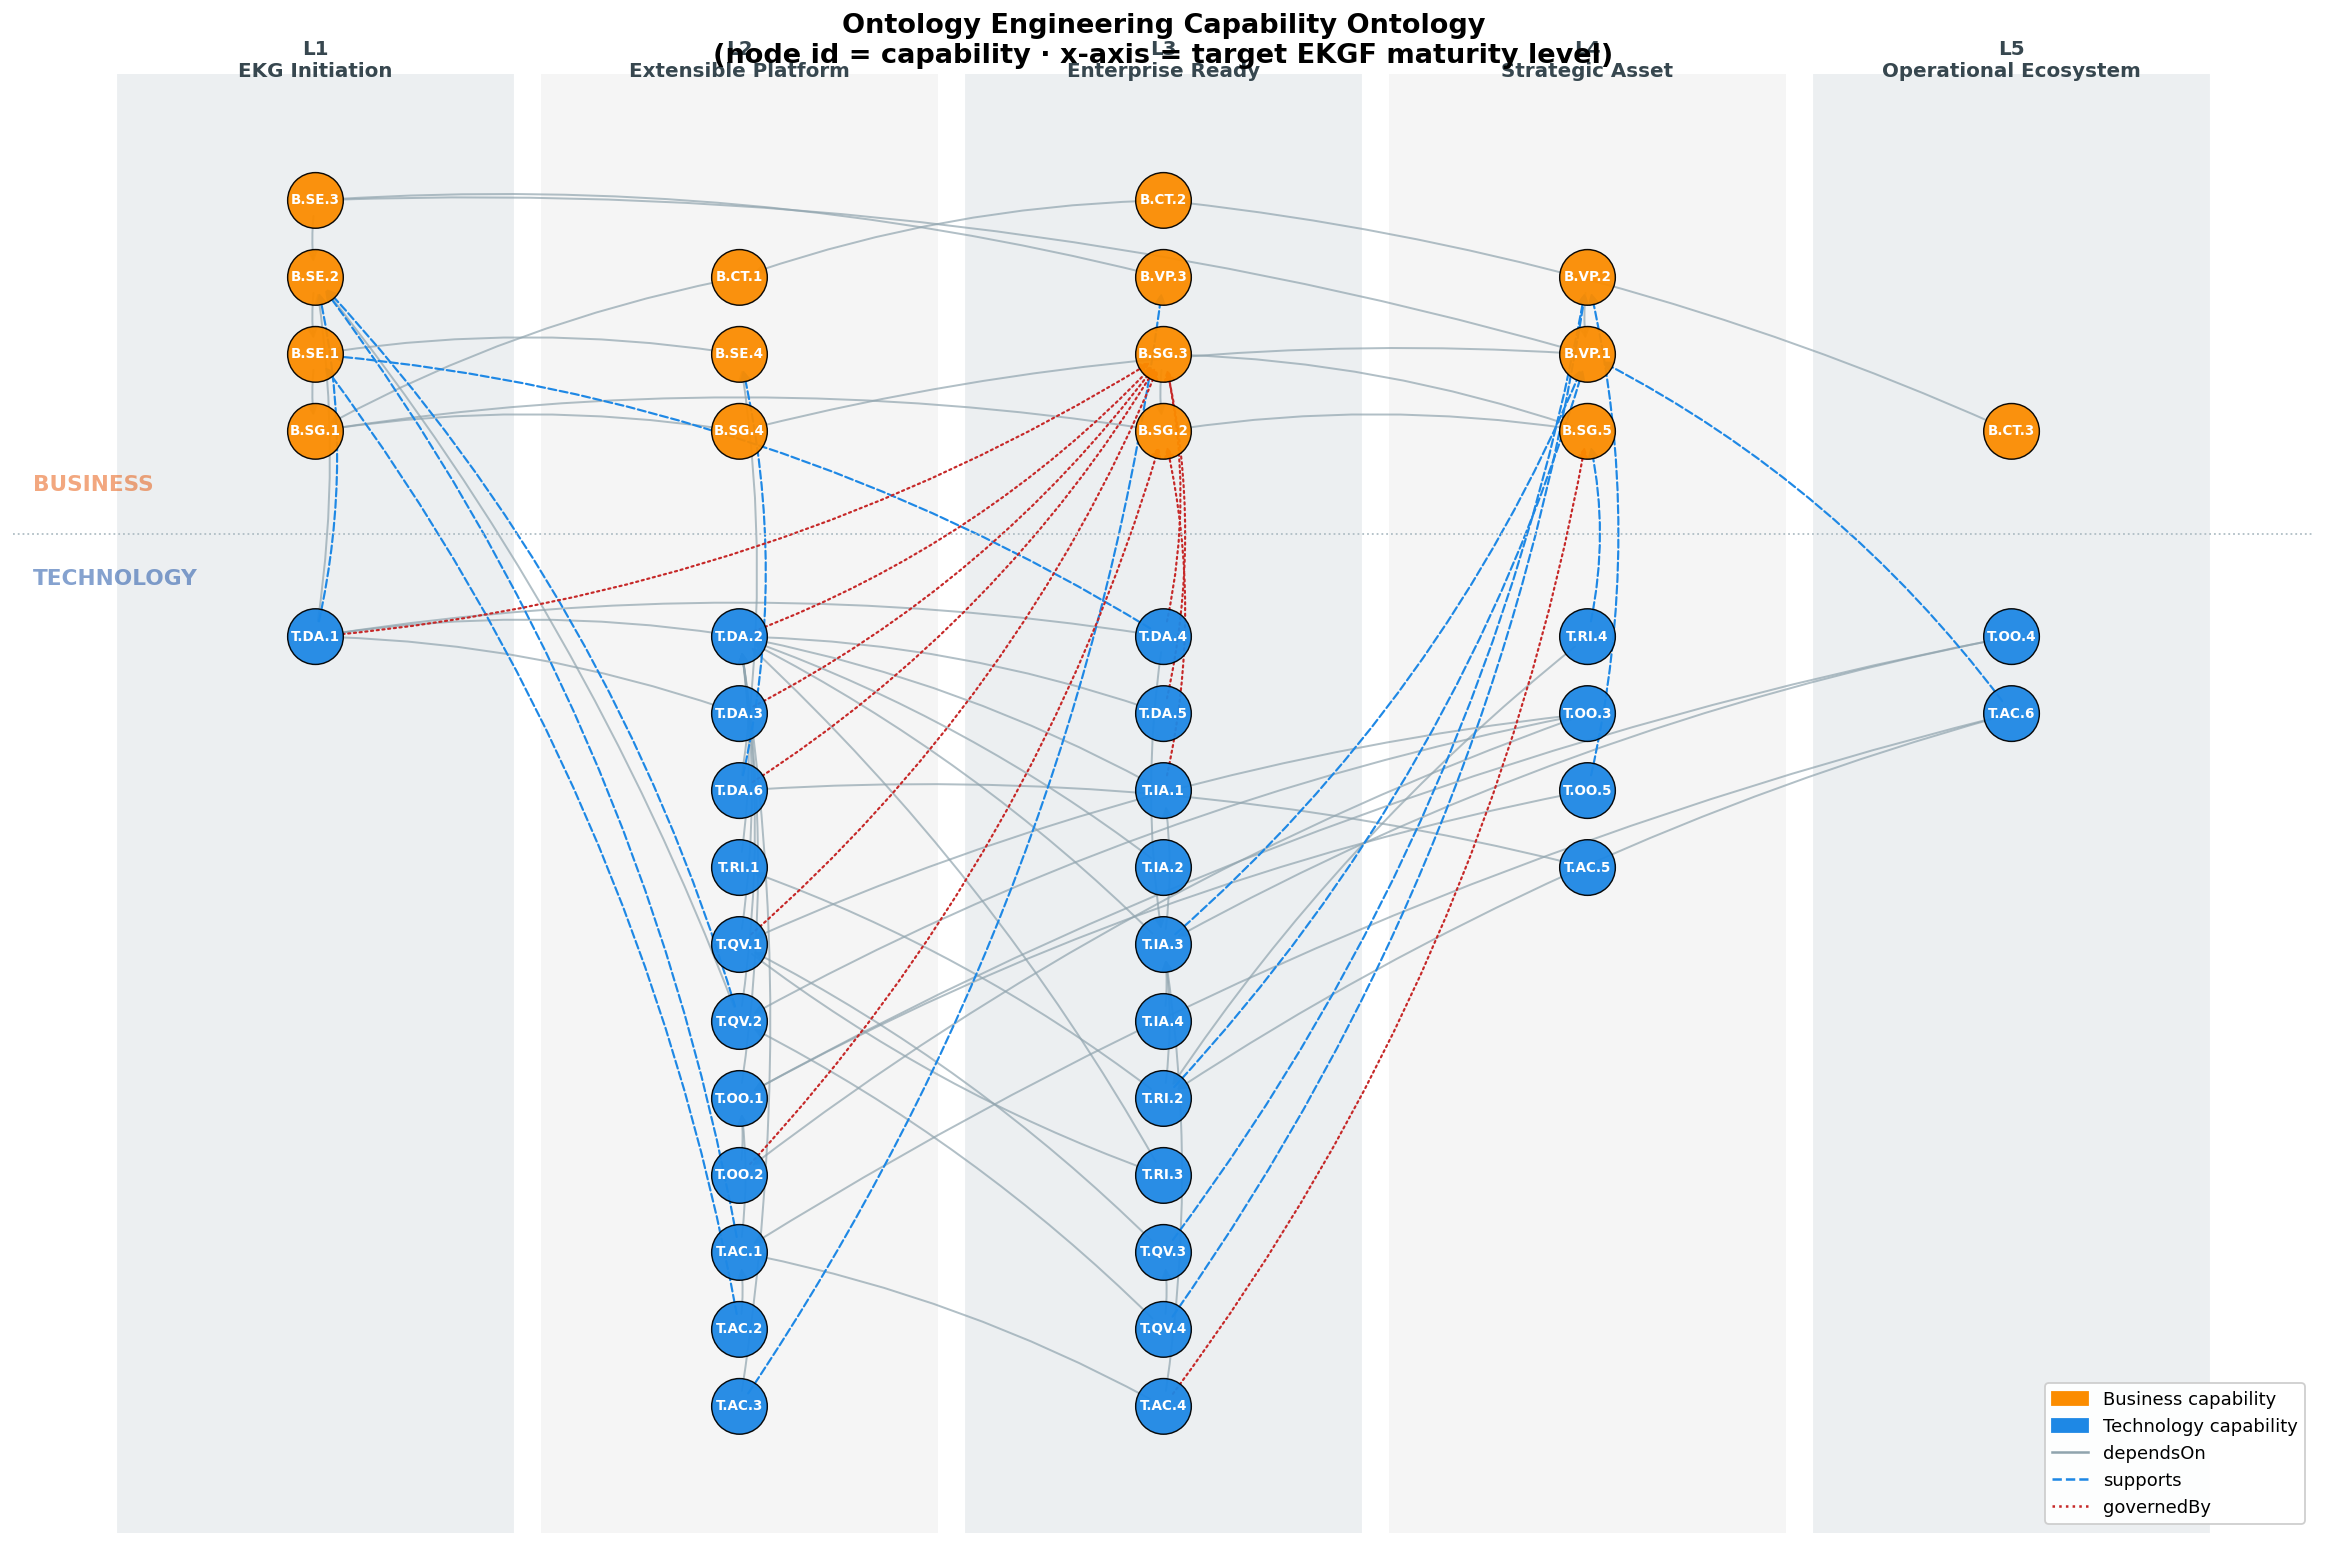

In [7]:
from IPython.display import Image, display
p = oec.draw_ontology_networkx('artifacts/_demo_onto.png')
display(Image(filename=p))

## 6 · RDF / OWL / SKOS export and SPARQL

In [8]:
import rdflib
g = rdflib.Graph(); g.parse(data=oec.to_turtle(), format='turtle')
print('triples:', len(g))
q = '''
PREFIX oec: <https://example.org/oec#>
PREFIX skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX ekgf: <https://maturity.ekgf.org/def#>
SELECT ?label ?lvl WHERE {
  ?c a oec:TechnologyCapability ; skos:prefLabel ?label ;
     oec:targetMaturityLevel ?L . ?L oec:levelNumber ?lvl .
  FILTER(?lvl >= 4)
} ORDER BY DESC(?lvl) ?label'''
for row in g.query(q):
    print(f'  L{row.lvl}  {row.label}')

triples: 738


  L5  Federation & Virtualization
  L5  LLM / AI Augmentation
  L4  Inference Explainability
  L4  Multilingual & Localization Support
  L4  Observability & Monitoring
  L4  Ontology CI/CD (OntoOps / DataOps)


## 7 · Regenerate every artifact
`python ontology_engineering_capabilities/build_artifacts.py` writes the full set into `artifacts/` and the requirements doc to `../REQUIREMENTS.md`.